kaggle datasets download dschettler8845/brats-2021-task1 -f BraTS2021_Training_Data.tar

tar -xf BraTS2021_Training_Data.tar

In [1]:
import os
print("SUJET =", repr(os.environ.get("SUJET")))

SUJET = '/home/cassa2/psy3019/projet_repro/BraTS2021_00002'


# Éléments nécéssaires au notebook

### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
from tqdm import tqdm
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import monai
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
# from utils.SurfaceDice import compute_dice_coefficient Ne fonctionne pas 
import skimage
# set seeds
torch.manual_seed(2023)
np.random.seed(2023)

In [3]:
# MOI ajout des imports qui sont partout dans le doc ici : 
import tarfile
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import seaborn as sns
import pickle
import pandas as pd # Ajouté pour les stats

In [4]:
#If your data is .tar format, you can run this cell to extract it
'''
# import tarfile localisation initiale 
file = tarfile.open('./BraTS2021_Training_Data.tar')
file.extractall('./brain_images')
file.close()
'''

"\n# import tarfile localisation initiale \nfile = tarfile.open('./BraTS2021_Training_Data.tar')\nfile.extractall('./brain_images')\nfile.close()\n"

# Notebook explicatif pour un sujet

In [5]:
# Chemins généraux : 
#data_path = '../source_data'
#sujet = 'BraTS2021_00002' 
#model_paths = '../code/models'
#slice_index = 60 # La couche ou la segmentation sera faite 

import os
from pathlib import Path

source_dir = Path(os.environ.get("SOURCE_DATA_DIR", "../source_data"))
output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "output_data"))
models_dir = Path(os.environ.get("MODELS_DIR", "../models"))
sujet = Path(os.environ.get("SUJET", "BraTS2021_00002")).name  

print(sujet)      

BraTS2021_00002


In [6]:
# Ouverture des scans originaux : le scan et la segmentation réelle (ground truth)
# Format : .nii.gz 

# Chemin de fichiers 
scan_path = f'{source_dir}/{sujet}/{sujet}_t2.nii.gz'
gt_path = f'{source_dir}/{sujet}/{sujet}_seg.nii.gz'

# Load les fichiers 
scan_obj = nib.load(scan_path)
gt_obj = nib.load(gt_path)

# Validation 
type(scan_obj) 

scan_data = scan_obj.get_fdata()
print('Scan data  :', type(scan_data), scan_data.shape)

gt_data = gt_obj.get_fdata()
print('Ground truth', type(gt_data), gt_data.shape)


Scan data  : <class 'numpy.ndarray'> (240, 240, 155)
Ground truth <class 'numpy.ndarray'> (240, 240, 155)


In [7]:
# Trouve les couches ou la tumeur est présente sur l'axe des z 
tumor_slices = np.where(gt_data.any(axis=(0, 1)))[0]
print(f"De la couche {tumor_slices.min()} à {tumor_slices.max()}")

# Sélectionne aléatoirement une couche parmis les options
# Le seed est sélectionné à partir du ID de participants 
subject_number = int(sujet.split("_")[1])
rng = np.random.default_rng(seed=subject_number)
slice_index = rng.integers(tumor_slices.min(), tumor_slices.max())
print(slice_index)

De la couche 33 à 118
104


In [8]:
# Préparation des scans 2d (images scan et gt original = 3d)

# Obtenir les slices (image 2d) pour la bonne couche 
def get_slice_pair(layer, scan_data, gt_data):
    return scan_data[:, :, layer],gt_data[:, :, layer]

# Mettre dans le format nécéssaire pour les modèles 
def sam_imput_format(scan_2d) : 
    if scan_2d.shape[-1]>3 and len(scan_2d.shape)==3:
        scan_2d = scan_2d[:,:,:3]
    if len(scan_2d.shape)==2:
        scan_2d = np.repeat(scan_2d[:,:,None], 3, axis=-1)
    return scan_2d

# Obtenir l'image 2d originale et sa segmentation associée (pour la couche données)
scan_2d_og,gt_2d = get_slice_pair(slice_index, scan_data, gt_data)

# Good format
scan_2d = sam_imput_format(scan_2d_og)

## Visualisation initiale

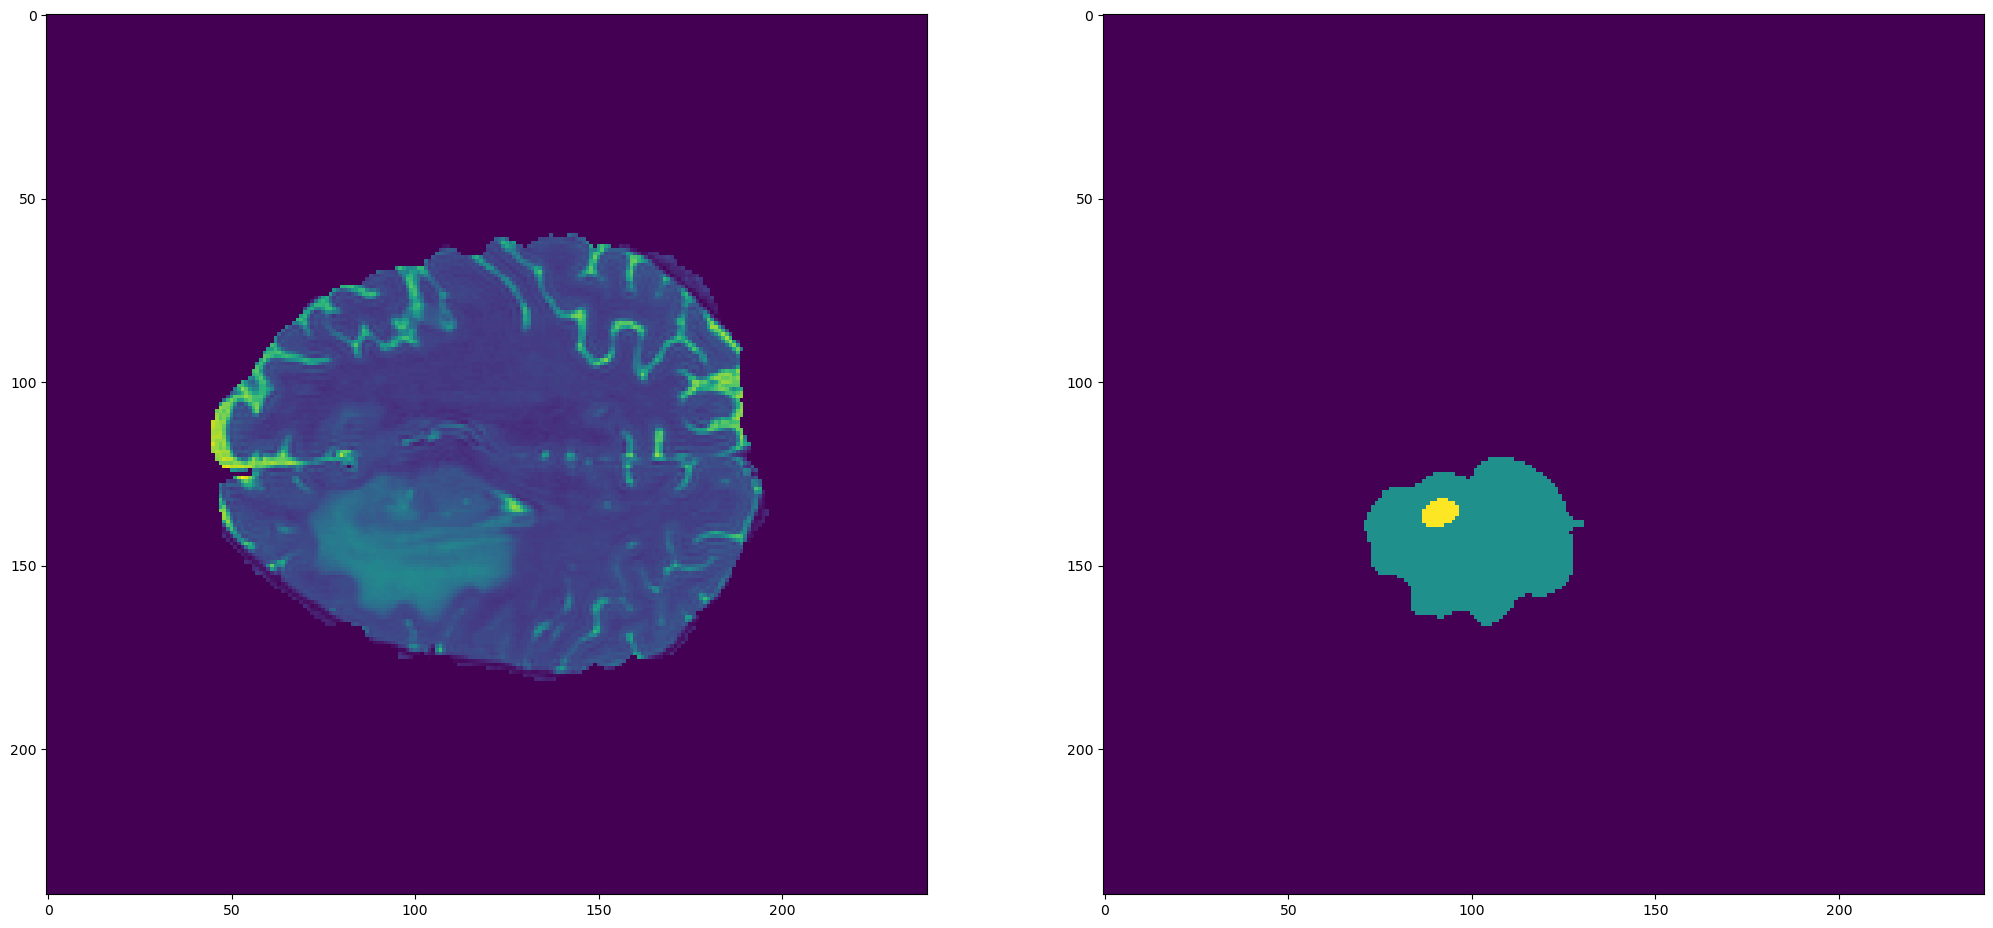

In [9]:
#Visualize the original MRI slice and corresponding mask
_, axs = plt.subplots(1, 2, figsize=(25, 25))
axs[0].imshow(scan_2d_og)
axs[1].imshow(gt_2d)
plt.show() 
plt.close()

## Segmentation par le modèle 1 : SAM 

### Initialisation des modèles

In [10]:
# Préparations pour les modèles 
from pathlib import Path

def initialisation_modeles(modeles_path) : 
    model_type = 'vit_b'
    #sam_model_checkpoint = '../models/sam_vit_b_01ec64.pth'
    #med_sam_model_checkpoint = '../models/sam_model_best.pth' # Not the original but matches the link

    sam_model_checkpoint = Path(modeles_path) / 'sam_vit_b_01ec64.pth'
    med_sam_model_checkpoint = Path(modeles_path) / 'sam_model_best.pth' 

    device = torch.device('cpu')

    sam_model = sam_model_registry[model_type](checkpoint=None)
    sam_model.load_state_dict(torch.load(sam_model_checkpoint, map_location=torch.device('cpu')))
    sam_model.to(device)

    med_sam_model = sam_model_registry[model_type](checkpoint=None)
    med_sam_model.load_state_dict(torch.load(med_sam_model_checkpoint, map_location=torch.device('cpu')))
    med_sam_model.to(device)

    sam_predictor = SamPredictor(sam_model)
    med_sam_predictor = SamPredictor(med_sam_model)

    print('Initialisation modèles terminée')
    return sam_predictor, med_sam_predictor, med_sam_model

# Load des modèles
sam_predictor, med_sam_predictor, med_sam_model = initialisation_modeles(models_dir)

Initialisation modèles terminée


### Préparation des scans 

Ici, on crée un objet qui indique au modèle dans quelle région se trouve l'objet à segmenter 

Ensuite le scan doit être dans le bon format pour le modèle

In [11]:
def get_bbox_from_mask(mask):
    '''Returns a bounding box from a mask'''
    y_indices, x_indices = np.where(mask > 0)
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    # add perturbation to bounding box coordinates
    H, W = mask.shape
    x_min = max(0, x_min - np.random.randint(0, 20))
    x_max = min(W, x_max + np.random.randint(0, 20))
    y_min = max(0, y_min - np.random.randint(0, 20))
    y_max = min(H, y_max + np.random.randint(0, 20))

    return np.array([x_min, y_min, x_max, y_max])

def preprocess_scan(scan_2d):
    lower_bound, upper_bound = np.percentile(scan_2d, 0.5), np.percentile(scan_2d, 99.5)
    scan_2d_pre = np.clip(scan_2d, lower_bound, upper_bound)
    scan_2d_pre = (scan_2d_pre - np.min(scan_2d_pre))/(np.max(scan_2d_pre)-np.min(scan_2d_pre))*255.0
    scan_2d_pre[scan_2d==0] = 0
    scan_2d_pre = np.uint8(scan_2d_pre)
    return scan_2d_pre

# Boite qui indique au modèle quelle région se trouve l'objet à segmenter 
gt_box = get_bbox_from_mask(gt_2d)

# Preprocess to get in the format needed by models :
scan_2d_pre = preprocess_scan(scan_2d)

# Validation 
print("Shape gt:", gt_2d.shape)
print("Shape scan:", scan_2d_pre.shape)

Shape gt: (240, 240)
Shape scan: (240, 240, 3)


## Segmentation des deux modèles

In [12]:
def get_sam_seg(scan_2d, bbox_raw, sam_predictor) :
    # predict the segmentation mask using the original SAM model
    sam_predictor.set_image(scan_2d)
    sam_seg, _, _ = sam_predictor.predict(point_coords=None, box=bbox_raw, multimask_output=False)
    #print(sam_seg.shape) 
    print("Segmentation SAM terminée")
    return sam_seg

def get_medsam_seg(scan_2d, bbox_raw, med_sam_model):

    device = 'cpu'

    med_sam_transform = ResizeLongestSide(med_sam_model.image_encoder.img_size)
    resize_img = med_sam_transform.apply_image(scan_2d)
    resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
    input_image = med_sam_model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
    assert input_image.shape == (1, 3, med_sam_model.image_encoder.img_size, med_sam_model.image_encoder.img_size), 'input image should be resized to 1024*1024'

    with torch.no_grad():
        
        H, W, _ = scan_2d.shape
        # pre-compute the image embedding
        ts_img_embedding = med_sam_model.image_encoder(input_image)
        # convert box to 1024x1024 grid
        bbox = med_sam_transform.apply_boxes(bbox_raw, (H, W))
        #print(f'{bbox_raw=} -> {bbox=}')

        box_torch = torch.as_tensor(bbox, dtype=torch.float, device=device)
        if len(box_torch.shape) == 2:
            box_torch = box_torch[:, None, :] # (B, 4) -> (B, 1, 4)
        
        sparse_embeddings, dense_embeddings = med_sam_model.prompt_encoder(
            points=None,
            boxes=box_torch,
            masks=None,
        )
        medsam_seg_prob, _ = med_sam_model.mask_decoder(
            image_embeddings=ts_img_embedding.to(device), # (B, 256, 64, 64)
            image_pe=med_sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
            )
        medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
        # convert soft mask to hard mask
        medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
        medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)

        medsam_seg = skimage.transform.resize(medsam_seg,(240,240))
        medsam_seg = skimage.util.img_as_ubyte(medsam_seg)
        #print(medsam_seg.shape)
        #print(medsam_seg)

        print("Segmentation MEDSAM terminée! :)")
        return medsam_seg

# Segmentation de SAM
sam_seg = get_sam_seg(scan_2d_pre, gt_box, sam_predictor)
medsam_seg = get_medsam_seg(scan_2d_pre, gt_box, med_sam_model)

Segmentation SAM terminée


Segmentation MEDSAM terminée! :)


# Métriques et explications 

### Dice score 



Le Dice score est la métrique utilisée originalement dans le projet, et une des plus communes pour examiner les différences entre deux segmentations. Ici, la différence est entre la segmentation d'un modèle et la segmentation de référence (ground truth). Cette mesure est fréquement utilisée pour évaluer des algorythmes de segmentations d'images médicale comme c'est le cas ici (Taha et Allan, 2015)

Sa formule est : 

![Metriques_generales](../formule_dice.png)
###### Source : « Indice de Sørensen-Dice ». Wikipédia, 10 septembre 2025. Wikipedia, https://fr.wikipedia.org/w/index.php?title=Indice_de_S%C3%B8rensen-Dice&oldid=228856381.

In [13]:
def compute_dice_coefficient(mask_gt, mask_pred):
    volume_sum = mask_gt.sum() + mask_pred.sum()  # |A| + |B| → nb de pixels dans chaque masque
    if volume_sum == 0:
        return 1.0                                 # cas spécial : les deux masques sont vides
    volume_intersect = (mask_gt & mask_pred).sum() # |A ∩ B| → pixels en commun
    return 2 * volume_intersect / volume_sum       # formule DICE

sam_dsc = compute_dice_coefficient(gt_2d > 0, sam_seg > 0)
medsam_dsc = compute_dice_coefficient(gt_2d > 0, medsam_seg > 0)

### Précision vs Recall

Prend les mêmes éléments que le dice score mais donne plus d'information sur ou sont les erreurs du modèle. 

- La précision est la proportion des items pertinents parmi l'ensemble des items proposés, peut s'interpréter comme la qualité de la segmentation. 
- le recall est la proportion des items pertinents proposés parmi l'ensemble des items pertinents, peut être vu comme une mesure d'exhaustivité. 

![image.png](../Précision_et_rappel.png)
###### Source : « Précision et rappel ». Wikipédia, 10 décembre 2025. Wikipedia, https://fr.wikipedia.org/w/index.php?title=Pr%C3%A9cision_et_rappel&oldid=231342967.

In [14]:
def get_tp_fp_fn(mask_gt, mask_pred):
    '''
    TP (True Positive): represents the number of FTU pixels that have been properly classified as FTU
    FP (False Positive): represents the number background pixels being misclassified as FTUs (due to misalignment)
    FN (False Negative): represents the number of FTU pixels being misclassified as background
    '''
    mask_gt   = mask_gt.astype(bool)
    mask_pred = mask_pred.astype(bool)
    tp = (mask_gt & mask_pred).sum()
    fp = (~mask_gt & mask_pred).sum() # Inverse du masque (donc pas tumeur) mais le modèle dit que non
    fn = (mask_gt & ~mask_pred).sum() # Inverse du prédit (pas tumeur) mais le modèle dit que oui

    return tp, fp, fn

def precision_recall(gt, pred) :
    tp, fp, fn = get_tp_fp_fn(pred, gt)
    denom_p = tp + fp
    denom_r = tp + fn

    precision = (tp / denom_p) if denom_p > 0 else 1.0
    recall = (tp / denom_r) if denom_r > 0 else 1.0
    return precision, recall

precision_sam, recall_sam = precision_recall(gt_2d > 0, sam_seg > 0)
precision_medsam, recall_medsam = precision_recall(gt_2d > 0, medsam_seg > 0)

### Métriques de périmetres

Les deux métriques comparés ici sont le Hausdorff Distance (HD) et la distance moyenne entre les segmentations. Ces métriques seraient complémentaires aux métriques de chevauchement et plus sensible à des erreurs par rapport à la frontière de la tumeur (Sharp et al., 2014)

- HD correspond à la plus grande distance entre les deux segmentations, comme on peut le voir sur l'image. Cette métrique quantifie la présence de grands débordements. 
- La distance moyenne est moins sensible aux outliers et est moins sensible aux valeurs extrêmes et reflète la qualité globale de l'alignement des contours, en moyennant les distances entre les deux surfaces dans les deux directions.

![image.png](../HD.png)
https://www.researchgate.net/figure/Hausdorff-Distance-between-point-sets-X-and-Y-18_fig6_342520628
###### Source : Jadon, Shruti. « A survey of loss functions for semantic segmentation ». arXiv:2006.14822, arXiv, 3 septembre 2020. arXiv.org, https://doi.org/10.48550/arXiv.2006.14822.

Les deux métriques ont comme performance parfaite une valeur de 0 

In [15]:
from scipy.ndimage import distance_transform_edt, binary_erosion

def compute_hd100(mask_gt, mask_pred, voxel_spacing=None):
    print(mask_gt.shape, mask_pred.shape)
    
    mask_gt   = mask_gt.astype(bool)
    mask_pred = mask_pred.astype(bool)

    if mask_pred.sum() == 0 or mask_gt.sum() == 0:
        return float("nan")

    sampling = voxel_spacing if voxel_spacing is not None else tuple([1.0] * mask_gt.ndim)

    surf_gt = mask_gt ^ binary_erosion(mask_gt)
    surf_pred = mask_pred ^ binary_erosion(mask_pred)

    dt_gt = distance_transform_edt(~mask_gt, sampling=sampling)
    dt_pred = distance_transform_edt(~mask_pred, sampling=sampling)

    dist_pred_to_gt = dt_gt[surf_pred]
    dist_gt_to_pred = dt_pred[surf_gt]

    return float(max(dist_pred_to_gt.max(), dist_gt_to_pred.max()))

def compute_avg_surf_dist(mask_gt, mask_pred, voxel_spacing=None):
    print(mask_gt.shape, mask_pred.shape)
    
    mask_gt   = mask_gt.astype(bool)
    mask_pred = mask_pred.astype(bool)

    if mask_pred.sum() == 0 or mask_gt.sum() == 0:
        return float("nan")

    sampling = voxel_spacing if voxel_spacing is not None else tuple([1.0] * mask_gt.ndim)

    # Gets only the surface voxels 
    surf_gt = mask_gt ^ binary_erosion(mask_gt)
    surf_pred = mask_pred ^ binary_erosion(mask_pred)

    # distance maps
    dt_gt = distance_transform_edt(~mask_gt, sampling=sampling)
    dt_pred = distance_transform_edt(~mask_pred, sampling=sampling)

    # distances surface → surface
    dist_pred_to_gt = dt_gt[surf_pred]
    dist_gt_to_pred = dt_pred[surf_gt]

    return dist_pred_to_gt.mean(), dist_gt_to_pred.mean()

# Enlève les dimmensions de 1 retournés par les modèles (nb images traités en mê temps)
sam_seg = sam_seg.squeeze()
medsam_seg = medsam_seg.squeeze()

# Ajout colone HD100 
HD100_sam = compute_hd100(gt_2d > 0, sam_seg > 0)
HD100_medsam = compute_hd100(gt_2d > 0, medsam_seg > 0)

# Ajout colone Average Surface Distance
AVG_seg2gt_sam, AVG_gt2seg_sam = compute_avg_surf_dist(gt_2d > 0, sam_seg > 0)
AVG_seg2gt_medsam, AVG_gt2seg_medsam = compute_avg_surf_dist(gt_2d > 0, medsam_seg > 0)

(240, 240) (240, 240)
(240, 240) (240, 240)
(240, 240) (240, 240)
(240, 240) (240, 240)


# Visualisation finale

Visualise l'image initiale, sa segmentation de référence et celle produite par les deux modèles. Des métriques pour chaque segmentation (Dice score, precision, recall) sont aussi indiquées

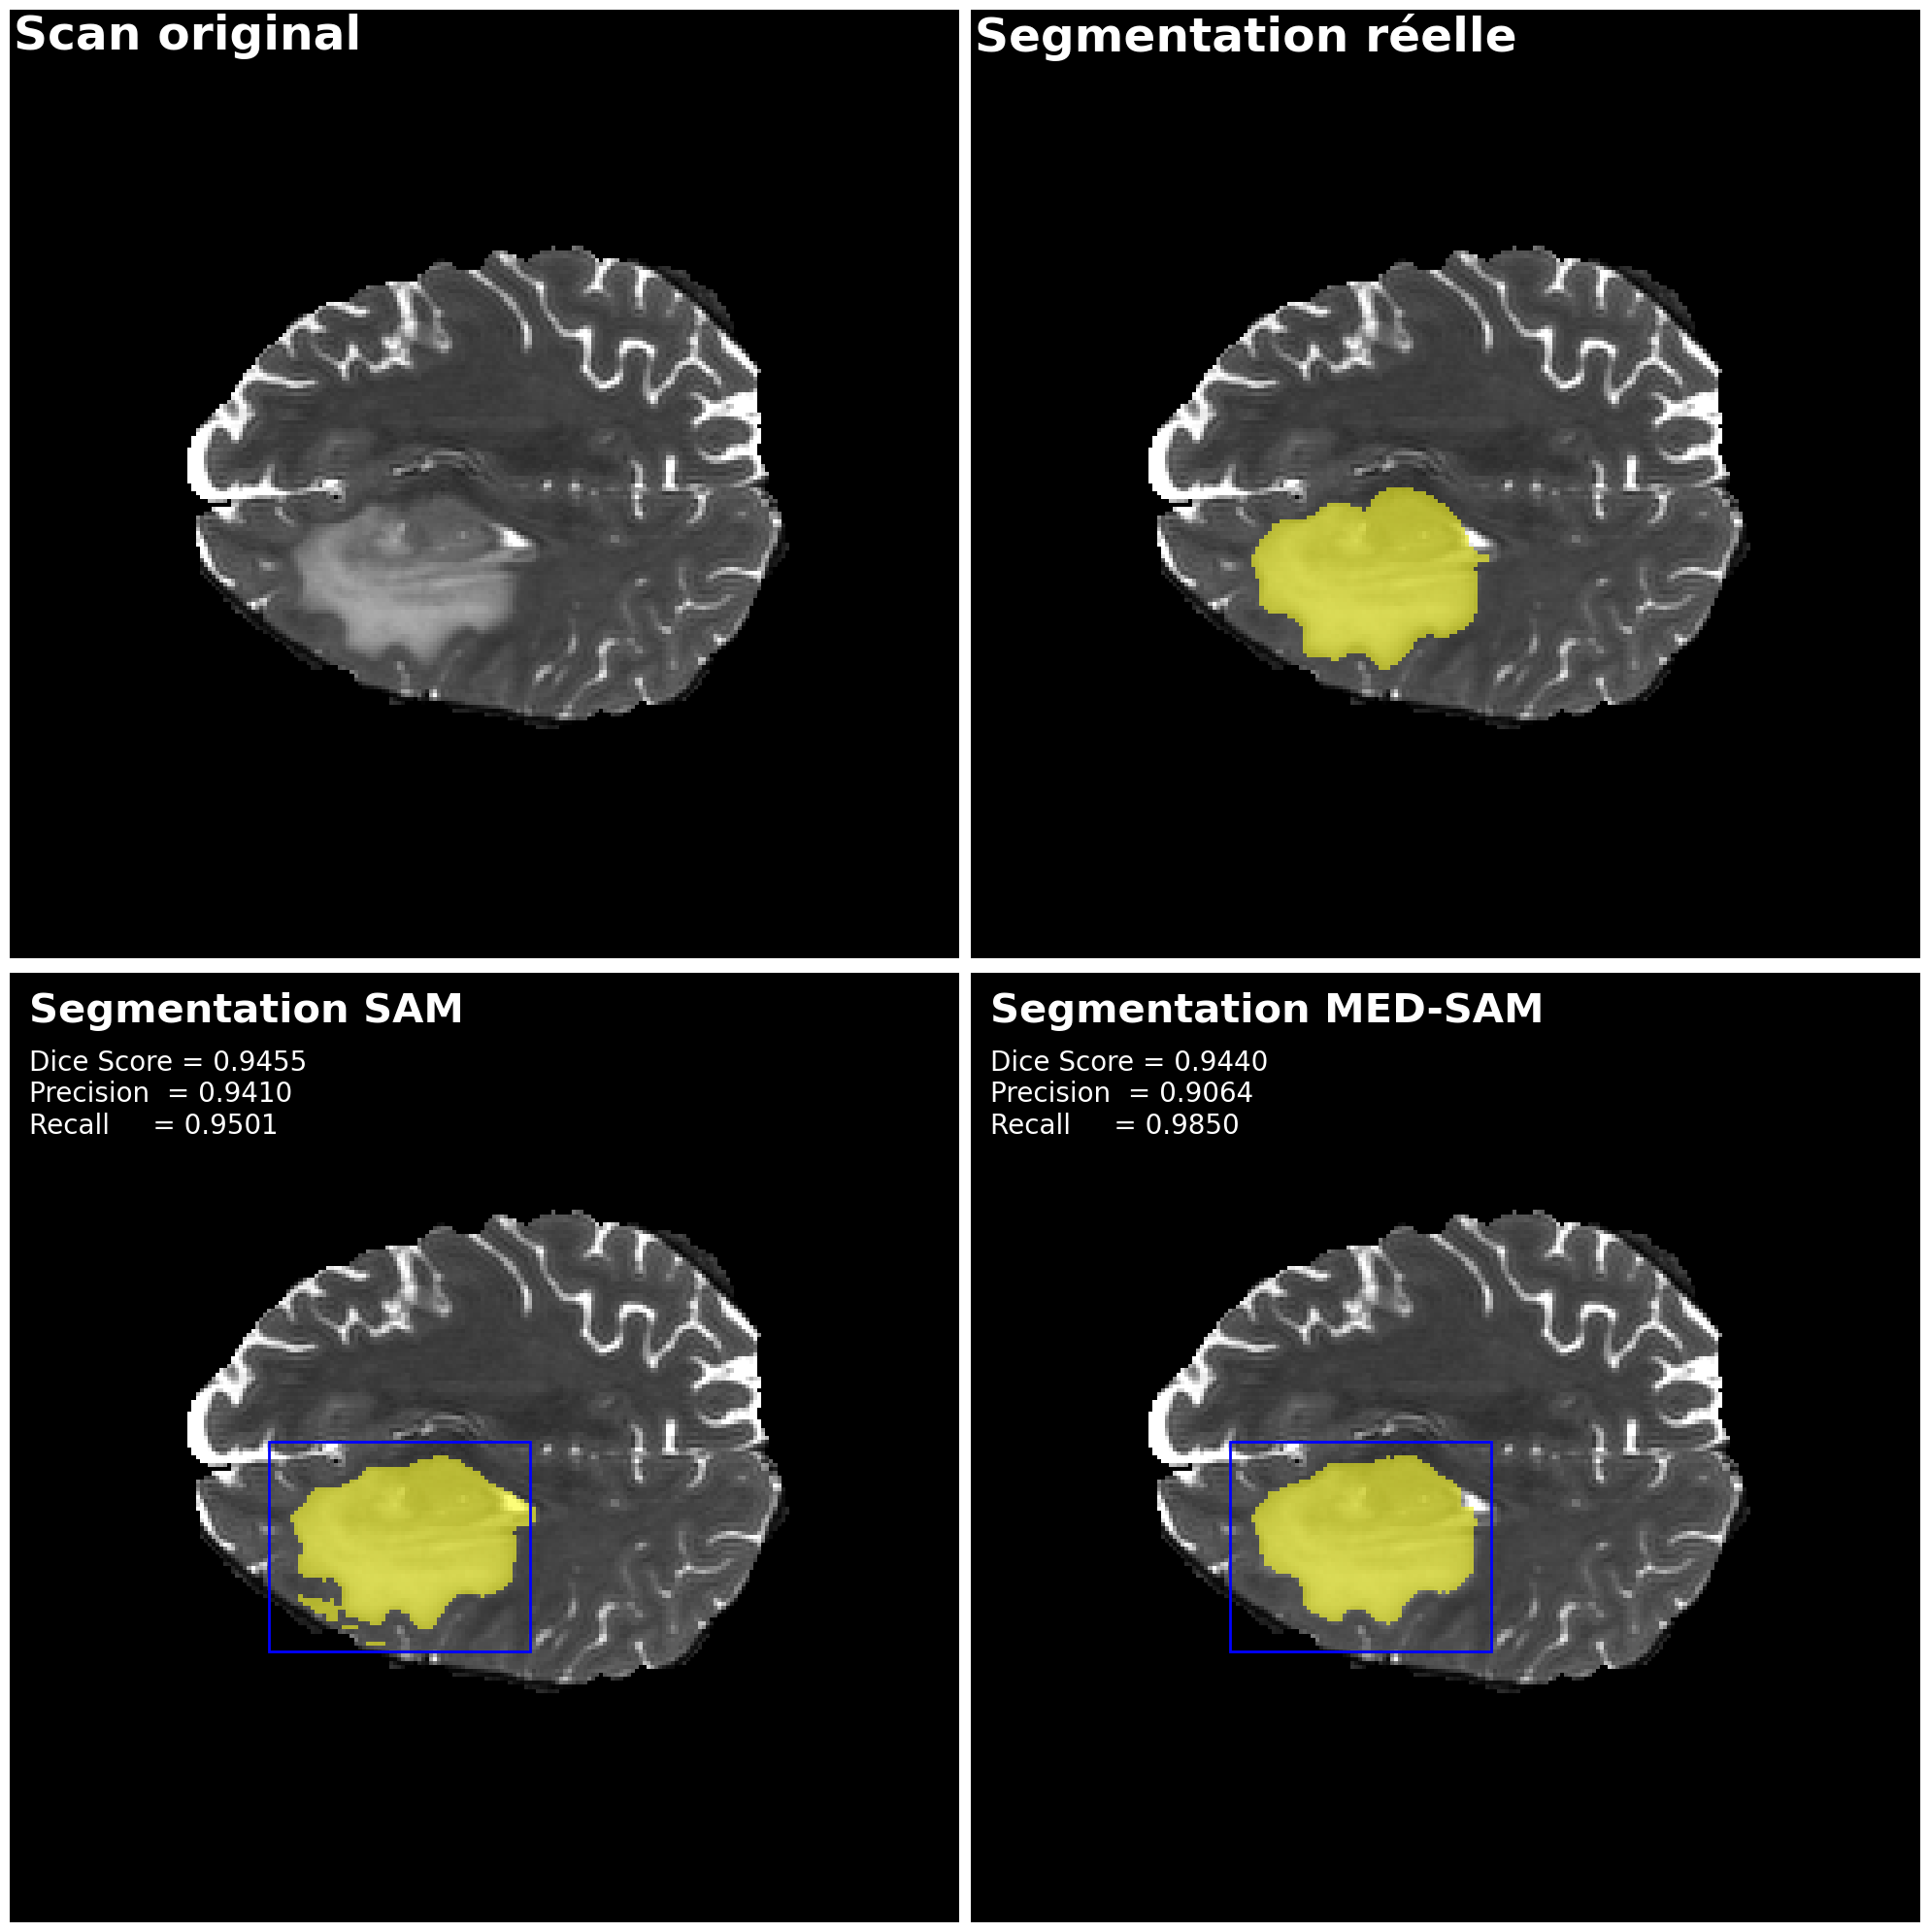

In [16]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

fig, axs = plt.subplots(2, 2, figsize=(20, 20))

# Scan original
axs[0, 0].imshow(scan_2d_pre, cmap='gray')
axs[0, 0].axis('off')
axs[0, 0].text(0.5, 0.5, 'Scan original', fontsize=35, fontweight='bold', horizontalalignment='left', verticalalignment='top', color='white')

# Scan + GT
axs[0, 1].imshow(scan_2d_pre)
show_mask(gt_2d > 0, axs[0, 1])        
axs[0, 1].axis('off')
axs[0, 1].text(0.5, 0.5, 'Segmentation réelle', fontsize=35, fontweight='bold', horizontalalignment='left', verticalalignment='top', color='white')

# SAM seg
axs[1, 0].imshow(scan_2d_pre)             
show_mask(sam_seg, axs[1, 0])     
show_box(gt_box, axs[1, 0])
# Titre 
axs[1, 0].text(0.02, 0.98, 'Segmentation SAM', 
               fontsize=30, fontweight='bold',
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 0].transAxes)

# Métriques 
metrics_text = (
    f'Dice Score = {sam_dsc:.4f}\n'
    f'Precision  = {precision_sam:.4f}\n'
    f'Recall     = {recall_sam:.4f}'
)
axs[1, 0].text(0.02, 0.92, metrics_text, 
               fontsize=20,
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 0].transAxes)

axs[1, 0].axis('off')


# MedSAM seg
axs[1, 1].imshow(scan_2d_pre)            
show_mask(medsam_seg, axs[1, 1])     
show_box(gt_box, axs[1, 1])
# Titre (grand)
axs[1, 1].text(0.02, 0.98, 'Segmentation MED-SAM', 
               fontsize=30, fontweight='bold',
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 1].transAxes)

# Métriques 
metrics_text = (
    f'Dice Score = {medsam_dsc:.4f}\n'
    f'Precision  = {precision_medsam:.4f}\n'
    f'Recall     = {recall_medsam:.4f}'
)
axs[1, 1].text(0.02, 0.92, metrics_text, 
               fontsize=20,
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 1].transAxes)

axs[1, 1].axis('off')

fig.tight_layout()



In [17]:
# Compréhension : 

# Les masques de tumeurs 
print("ground truth", np.unique(gt_2d))
print("predicted SAM", np.unique(sam_seg))
print("predicted mSAM", np.unique(medsam_seg))

'''
Pour le masque ground truth, il y a plusieurs valeurs qui sont je pense le type la région 

Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edematous/invaded tissue (ED — label 2), 
and the necrotic tumor core (NCR — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest 
BraTS summarizing paper. 

Mais nous on prédit juste la tumeur en général, donc on veut juste les valeurs > 0 

C'est pour ça que quand il les plogue il met gt_2d>0

'''
print("ground truth", np.unique(gt_2d>0))

ground truth [0. 2. 4.]
predicted SAM [False  True]
predicted mSAM [0 1]
ground truth [False  True]
